# **Automated Analysis Pipeline Notebook**
## Diabetes Prediction and Automated Analysis

**Student Name:** `Savannah Wallis`

---

**Dataset:** Pima Indians Diabetes Database (NIH–NIDDK)

**Description:** This dataset contains diagnostic measurements from women aged 21 years or older of Pima Indian heritage. The binary prediction task is to classify whether a patient has diabetes based on the available predictor variables.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation.

**Note:** This dataset is used for instructional and demonstration purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

# Upload Your Dataset

**Major Section Purpose:**

This section is vital to starting the analytical pipeline. We access the data, gain basic insights about the shape, types, missing values and more. These findings are the basis for how the data is treated in the rest of the workflow.

**Conditional Logic in the Workflow:**

The main conditional logic occuring in this section is within the data upload code. The user does not have to change the file type or extension because the if and elif statements address all possibilities and can read the data depending on the extension.

**Statistical and Machine Learning Methods:**

Some basic statistical analysis here helps inform the pipeline as we examine summary statistics, such as count, mean, ranges, and other important metrics. This allows us to make possible connections between variables and validate values, which are important steps before the EDA process.

**Influence of Dataset Characteristics/User-Defined Goals**

This section is essential for defining the characteristics of the dataset, such as the number of predictors, numerical centers, and the target's role. The shape and overall examination of the dataset allows us to conduct this next EDA process more appropriately.



In [ ]:

# Uploading the file and conditional extension

from google.colab import files
import pandas as pd
import io
from pathlib import Path

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one data file.")

filename = next(iter(uploaded))
extension = Path(filename).suffix.lower()
file_data = io.BytesIO(uploaded[filename])

if extension in [".csv", ".tsv", ".txt"]:
    # Automatically detect the delimiter.
    df = pd.read_csv(file_data, sep=None, engine="python")

elif extension in [".xlsx", ".xls"]:
    # Load the first worksheet.
    df = pd.read_excel(file_data)

elif extension == ".json":
    df = pd.read_json(file_data)

elif extension == ".parquet":
    df = pd.read_parquet(file_data)

else:
    raise ValueError(
        f"'{extension}' files require a different reader. "
        "Supported formats: CSV, TSV, TXT, XLSX, XLS, JSON, and Parquet."
    )

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

# View the data
display(df.head())

Saving Example Dataset_Diabetes.csv to Example Dataset_Diabetes (1).csv
Successfully loaded: Example Dataset_Diabetes (1).csv
Rows: 768 | Columns: 9


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# @title **View first 10 rows of data**

df.head(10) # CHANGE NUMBER TO INCREASE OR DECREASE THE NUMBER OF ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']


In [ ]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(768, 9)

In [ ]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pregnancies     768 non-null    int64  
 1   Glucose         768 non-null    int64  
 2   D_BP            768 non-null    int64  
 3   Skin_Thickness  768 non-null    int64  
 4   Insulin         768 non-null    int64  
 5   BMI             768 non-null    float64
 6   Pedigree        768 non-null    float64
 7   Age             768 non-null    int64  
 8   Outcome         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Pregnancies[int64],768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose[int64],768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
D_BP[int64],768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
Skin_Thickness[int64],768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin[int64],768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI[float64],768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
Pedigree[float64],768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age[int64],768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome[int64],768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [ ]:
# @title **Identify known impossible values for later imputation**

import numpy as np

variables_to_replace_zeros = [
    'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI'
]

for variable in variables_to_replace_zeros:
    if variable in df.columns:
        df[variable] = df[variable].replace(0, np.nan)

print("Impossible zeros replaced with missing values.")
print("The ML pipeline will impute missing predictors using training data.")

Impossible zeros replaced with missing values.
The ML pipeline will impute missing predictors using training data.


In [ ]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Outcome"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

Predictors requiring imputation:


,Missing values
Glucose,5
D_BP,35
Skin_Thickness,227
Insulin,374
BMI,11


Block #4 will automatically fill these using training-set medians.


In [ ]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
variable = 'BMI'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {variable}:")
print("")

# Get the description and round it to 3 decimal places
description = df[variable].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of BMI:

count    757.000
mean      32.457
std        6.925
min       18.200
25%       27.500
50%       32.300
75%       36.600
max       67.100
Name: BMI, dtype: float64


In [ ]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Pregnancies,768,0
1,Glucose,763,5
2,D_BP,733,35
3,Skin_Thickness,541,227
4,Insulin,394,374
5,BMI,757,11
6,Pedigree,768,0
7,Age,768,0
8,Outcome,768,0


In [ ]:
# @title **View 15 random rows of data**
np.random.seed()
df.sample(n=15) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
527,3,116.0,74.0,15.0,105.0,26.3,0.107,24,0
240,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0
730,3,130.0,78.0,23.0,79.0,28.4,0.323,34,1
103,1,81.0,72.0,18.0,40.0,26.6,0.283,24,0
548,1,164.0,82.0,43.0,67.0,32.8,0.341,50,0
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0
624,2,108.0,64.0,NaN,NaN,30.8,0.158,21,0
705,6,80.0,80.0,36.0,NaN,39.8,0.177,28,0
753,0,181.0,88.0,44.0,510.0,43.3,0.222,26,1
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,0


In [ ]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Outcome' # CHANGE THIS VARIABLE
new_data_type = 'category' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Outcome' variable changed from int64 to category

Note: You can revise the code to change the data type for a different variable.


## **Exploratory Data Analysis**

**Major Section Purpose:**

This section is extremely important exploratory work for further understanding variable correlations, distributions, and visualizations to compare the distribution of a variable across groups. This informs the analytica pipeline by ultimately preparing for how we may approach predictive methods and data science models in the last section. If we find confounding influences or interactions between variables, this may change our entire data science methodology.

**Conditional Logic in the Workflow:**

Conditional logic is directly present in the manifestation of histogram visualizations. It gives the user an option to specify the number of bins using if statements. If no bins are specified then automatic binning takes place. This conditional logic is a simple example of how the user experiences a bit of customization in the pipeline.

**Statistical and Machine Learning Methods:**

There are several statistical tests being applied in this section. The various correlation tests and heat maps provide context behind the predictor and target relationships. Pearson's is for more linear relationships, Spearman's is a non-parametric measurement, and Phi-K handles various data types. The visualizations are also expressing various distributions, means, variance, and medians across variables.

**Influence of Dataset Characteristics/User-Defined Goals**

The dataset and the user's goals absolutely takes part in how this section was shaped. The goal is clearly to deeply understand the correlation characteristics of the variables from all angles. The visualizitions especially focus on the target variable "outcome" and how is relates to predictors. Focusing on these aspects of the data will help the user's end goal of making an evidence-based machine learning model.

In [ ]:
# @title **Pearson's correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
D_BP,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
Skin_Thickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
Pedigree,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


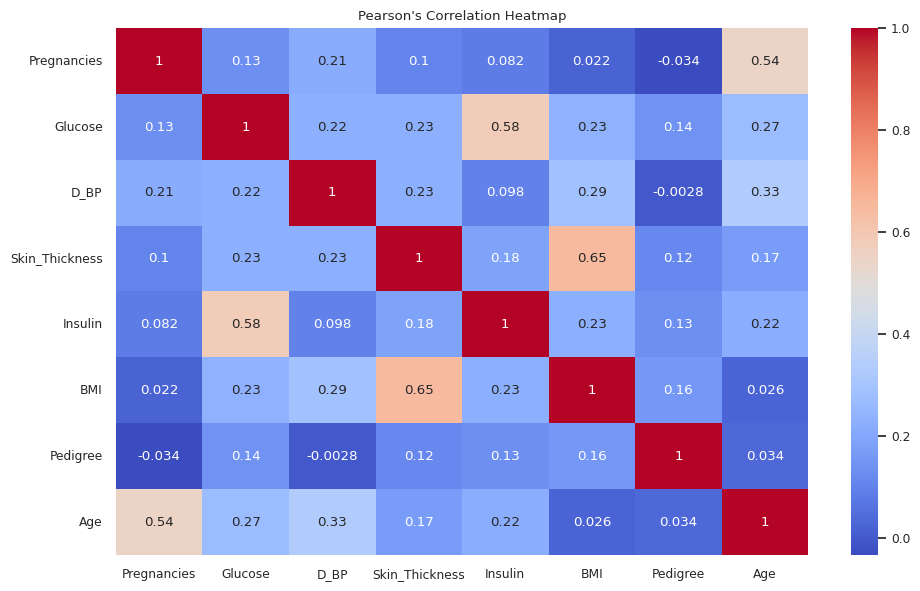

In [ ]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr(method='spearman')

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.129547,0.194103,0.086734,0.127859,0.000279,-0.043242,0.607216,0.198689
Glucose,0.129547,1.000000,0.249415,0.229815,0.658813,0.227761,0.090596,0.283315,0.483364
D_BP,0.194103,0.249415,1.000000,0.248017,0.130463,0.299176,0.008511,0.370609,0.177227
Skin_Thickness,0.086734,0.229815,0.248017,1.000000,0.245188,0.685380,0.074979,0.231132,0.265397
Insulin,0.127859,0.658813,0.130463,0.245188,1.000000,0.303515,0.130262,0.267437,0.377300
BMI,0.000279,0.227761,0.299176,0.685380,0.303515,1.000000,0.136138,0.121119,0.309324
Pedigree,-0.043242,0.090596,0.008511,0.074979,0.130262,0.136138,1.000000,0.042909,0.175353
Age,0.607216,0.283315,0.370609,0.231132,0.267437,0.121119,0.042909,1.000000,0.309040
Outcome,0.198689,0.483364,0.177227,0.265397,0.377300,0.309324,0.175353,0.309040,1.000000


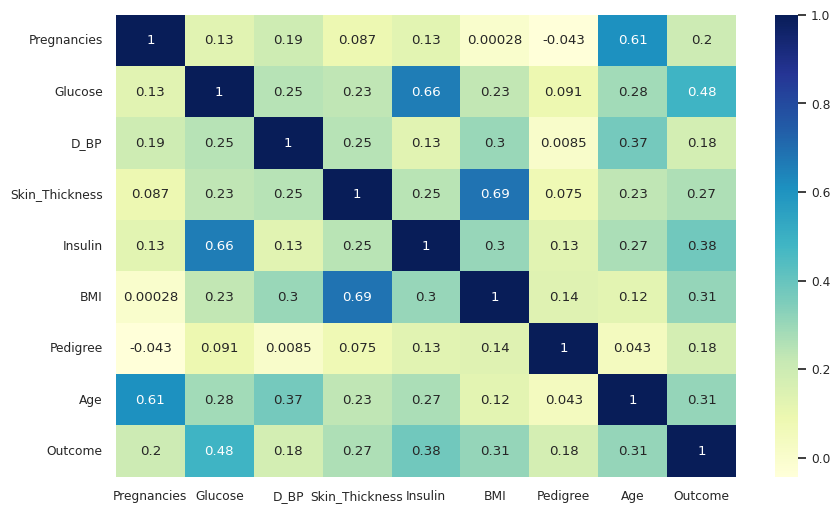

In [ ]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="YlGnBu");

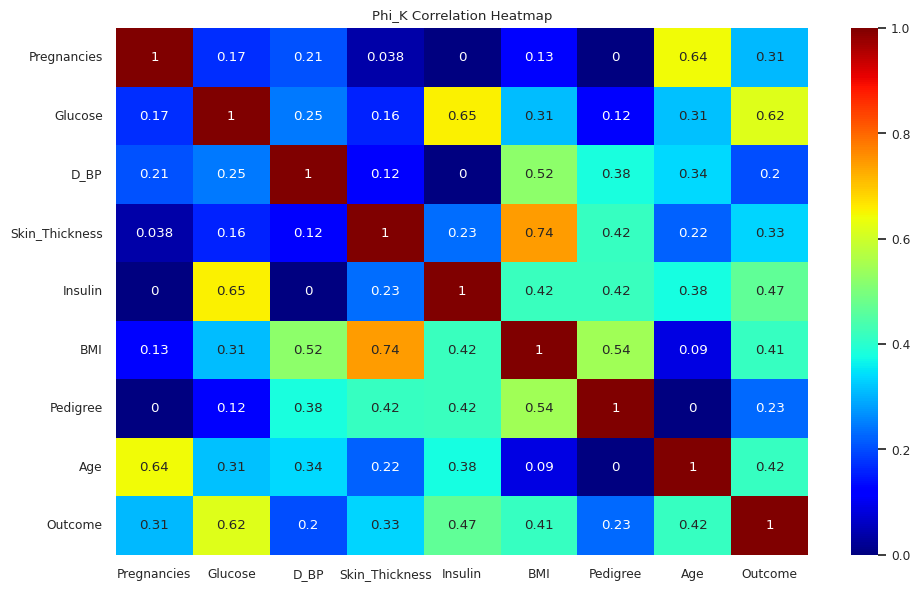

In [ ]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Identify interval (numerical) columns
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

# Compute and plot Phi-K correlation matrix with interval columns specified
phik_corr = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()

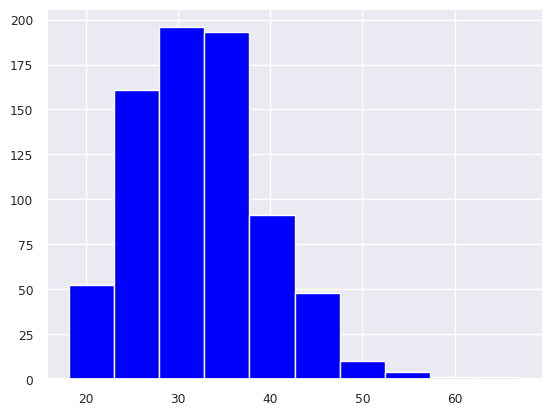

In [ ]:
# @title **Example of a histogram**
plt.hist(df['BMI'], color='blue'); # CHANGE VARIABLE HERE

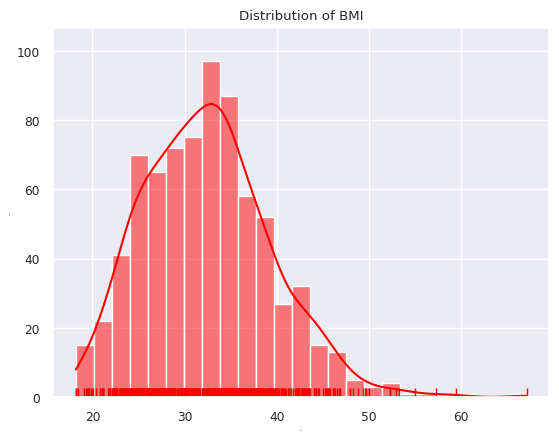

In [ ]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "BMI"

sns.histplot(data=df, x=variable, color="red", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

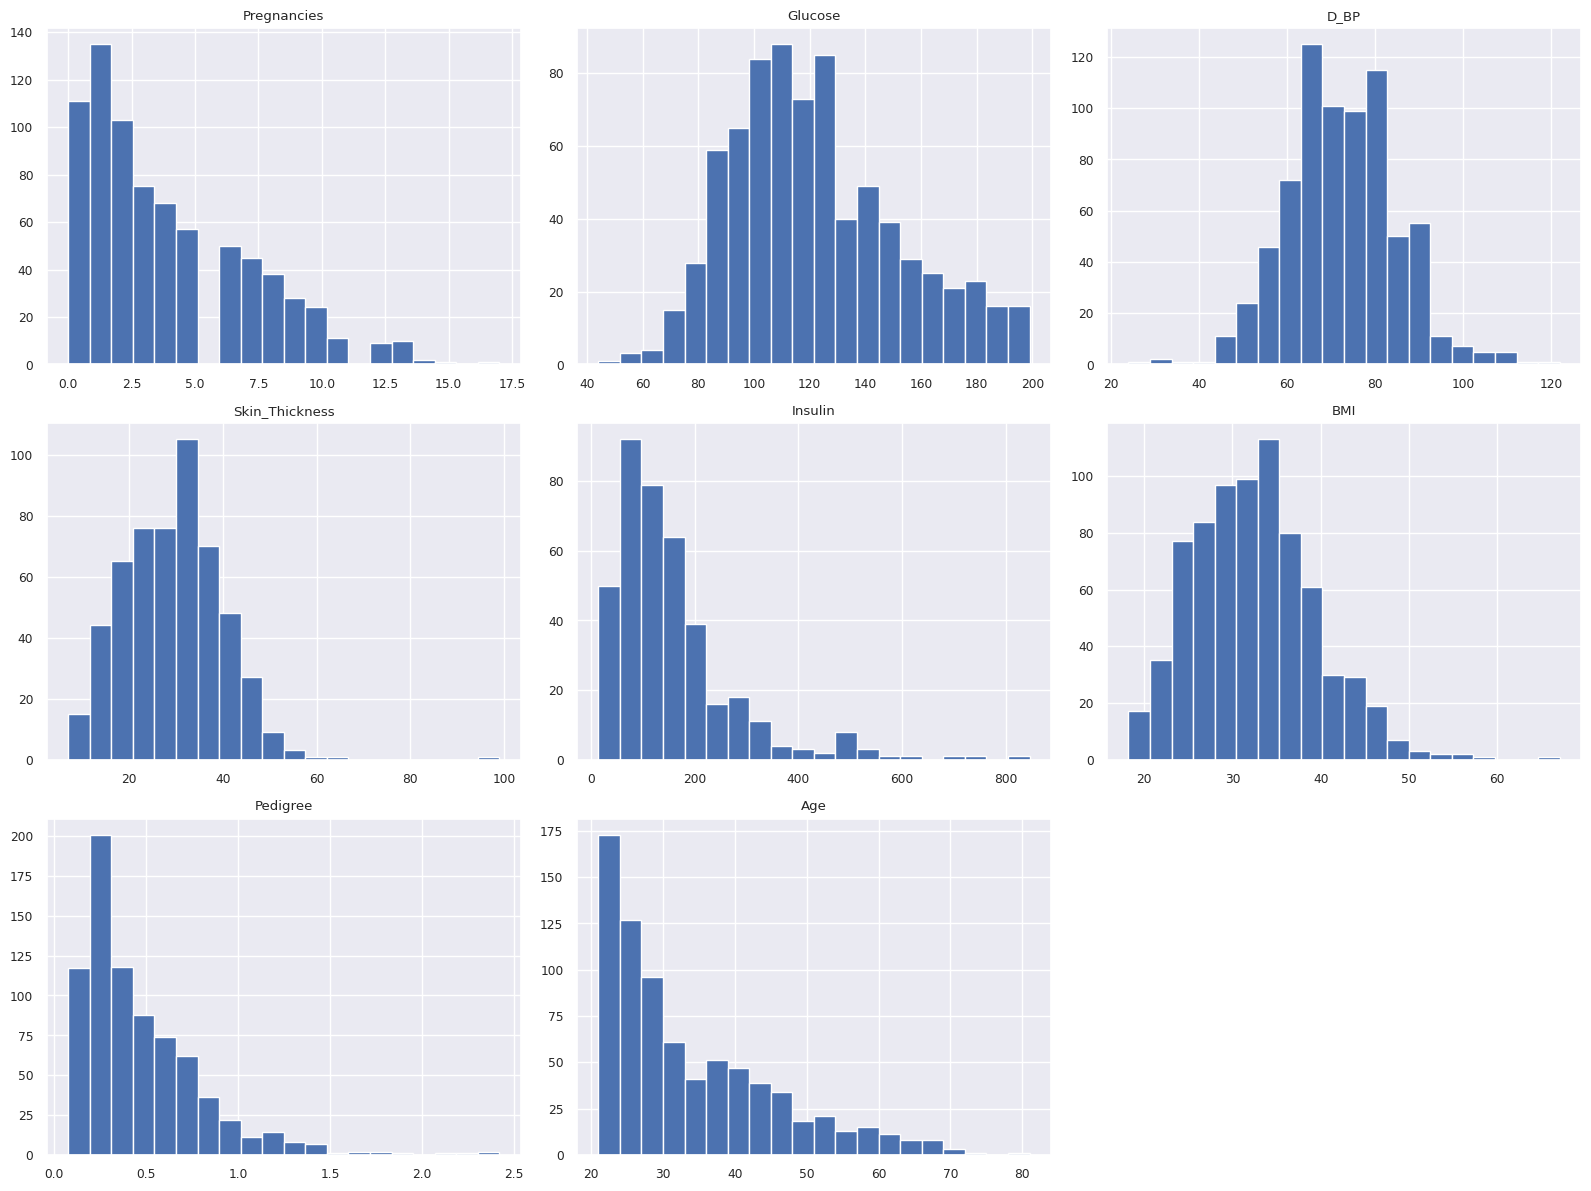

In [ ]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

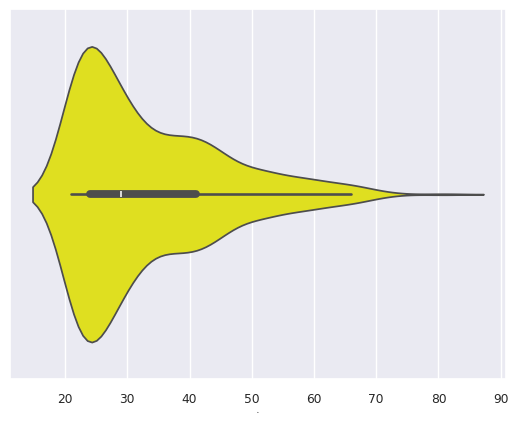

In [ ]:
# @title **Example of a violin plot**
sns.violinplot(df['Age'], color='yellow', orient='h'); # CHANGE VARIABLE AND COLOR HERE

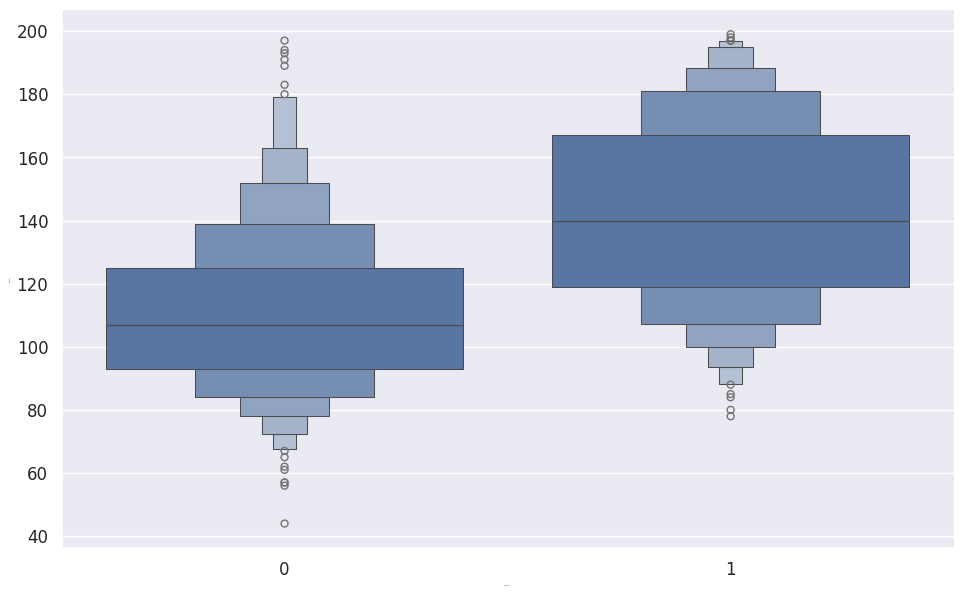

In [ ]:
# @title **Example of categorical plot**
# Define the plot variables
x_var = "Outcome"
y_var = "Glucose"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


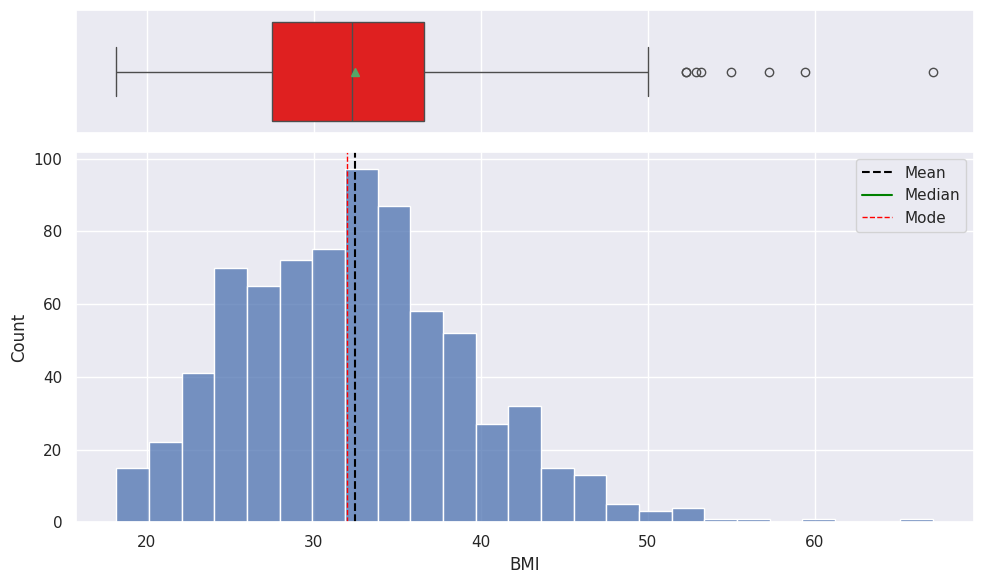

In [ ]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df.BMI) # CHANGE THE CONTINUOUS VARIABLE HERE

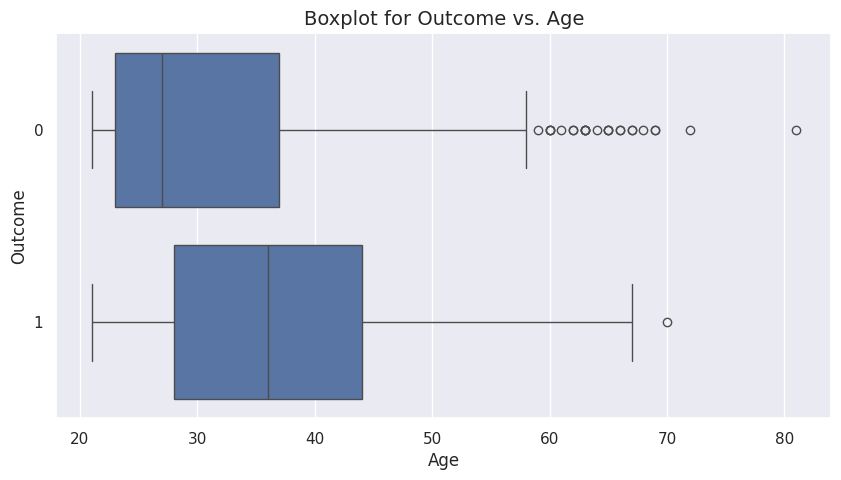

In [ ]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Age" # CHANGE VARIABLE HERE
y_var = "Outcome"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

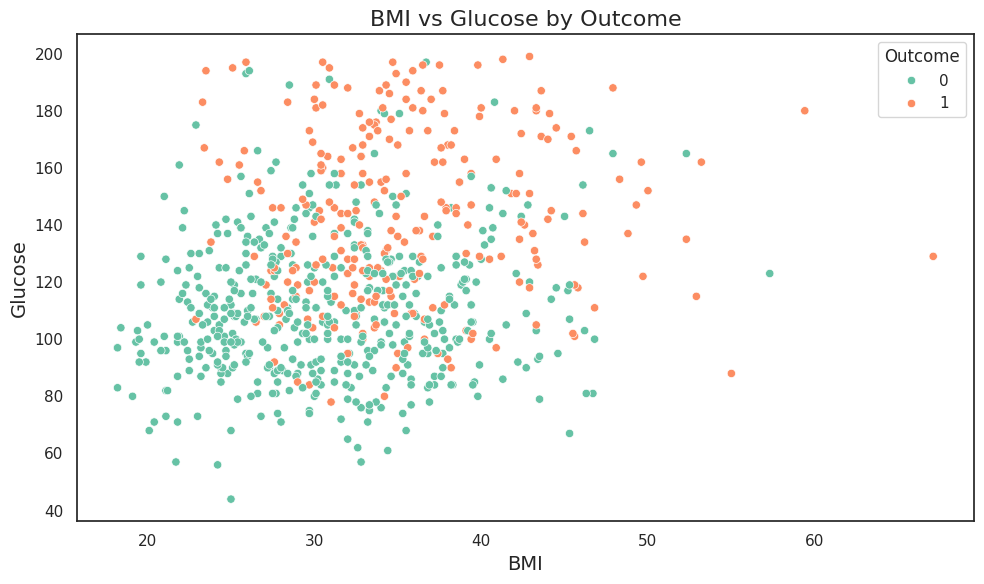

In [ ]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df, palette='Set2')

# Add title and axis labels
plt.title('BMI vs Glucose by Outcome', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Glucose', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

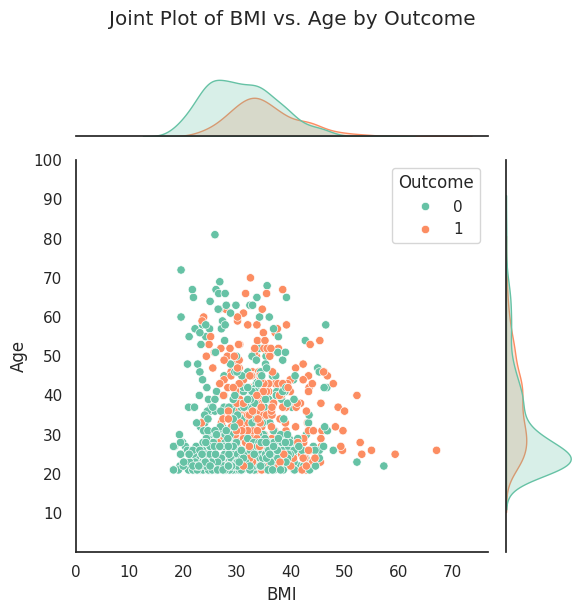

In [ ]:
# @title **Example of a joint plot (3 variables)**
g = sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE
    hue='Outcome',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of BMI vs. Age by Outcome", y=1.02)
plt.tight_layout()
plt.show()

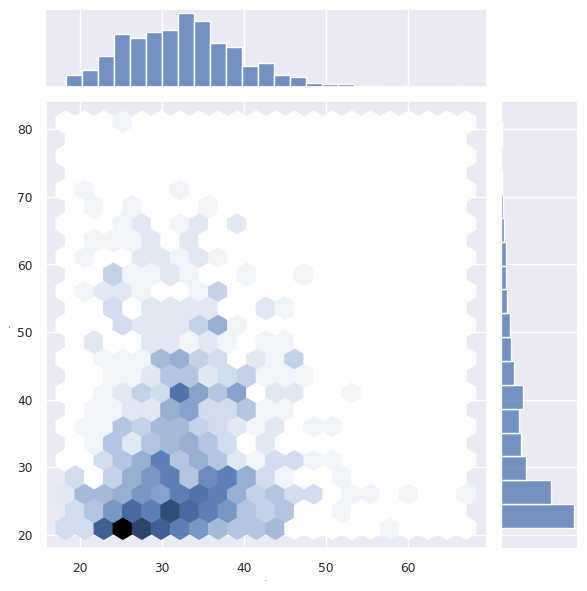

In [ ]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

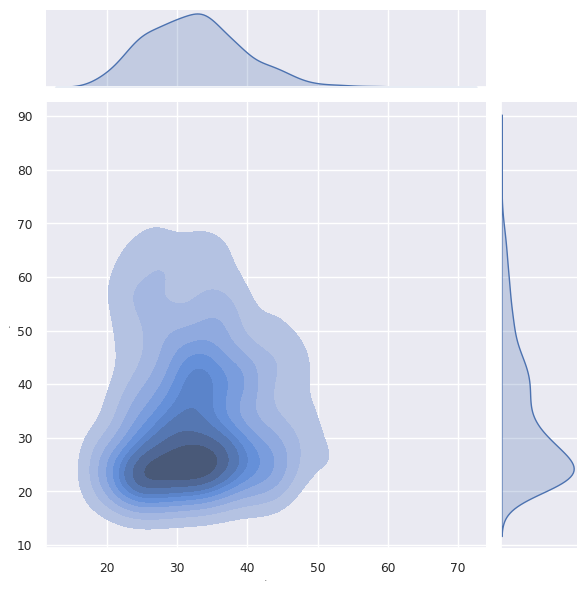

In [ ]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

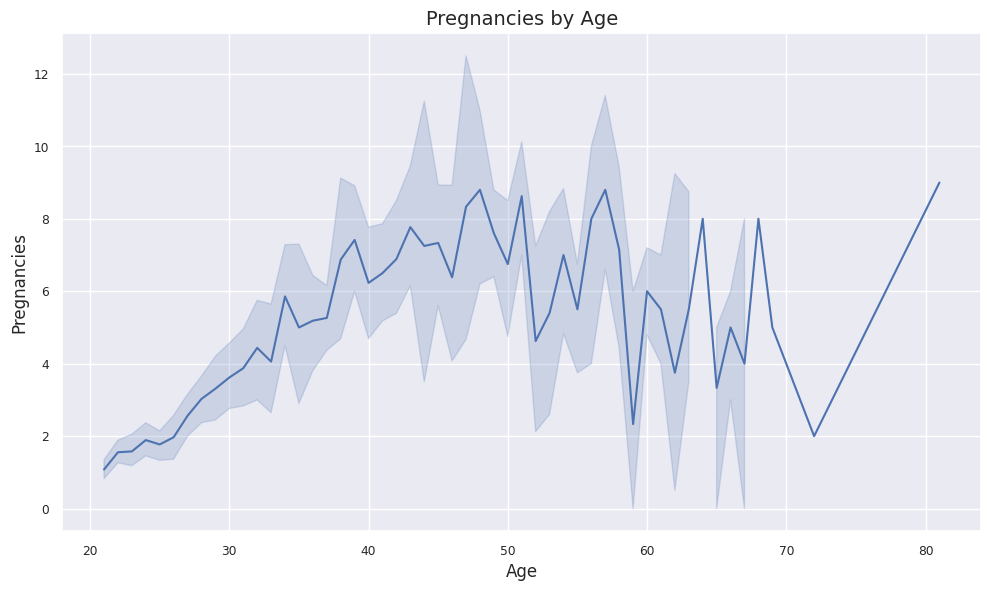

In [ ]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'Age' # CHANGE VARIABLE HERE
y_col = 'Pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

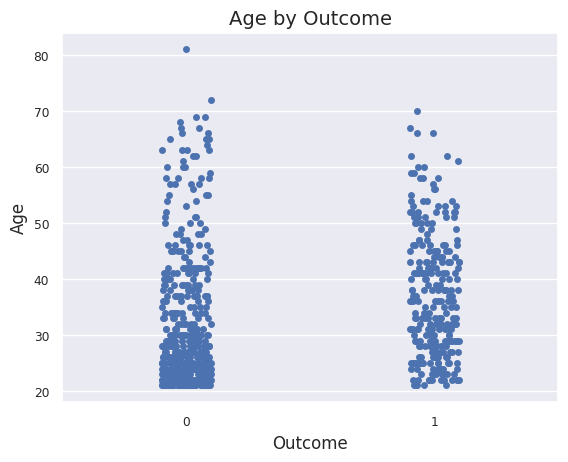

In [ ]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Outcome"  # CHANGE VARIABLE HERE
y_var = "Age"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

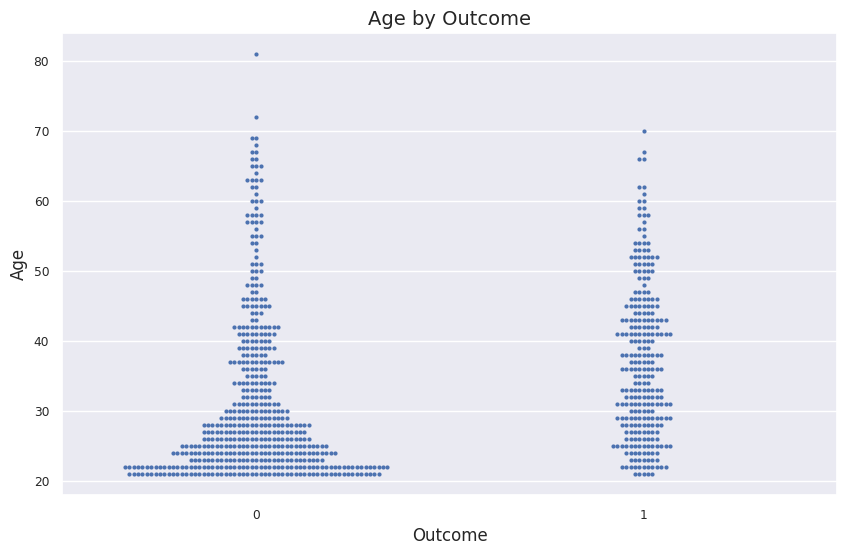

In [ ]:
# @title **Example of a swarm plot**

x_var = "Outcome"
y_var = "Age"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

**Link to other data visualizations: https://seaborn.pydata.org/examples/index.html**

## **Inferential Statistics**

**Major Section Purpose:**

This section is also important for the pipeline, as it uses statistical tests, such as ANOVA, t-tests, and chi-square tests. These find evidence for differences or associations in the population compared to the data sample given. These differences must be kept in mind, as the machine learning model is likely only trained and tested on the small sample size and may not be applicable to the actual population.

**Conditional Logic in the Workflow:**

There are several examples of conditional logic in the workflow here. The code blocks often first use if statements to ensure the dataset has enough observations or groups to run. If statements are also used to give conclusions about the p-value result. These are mostly used to ensure the test is running accurately, with the right input and interprets results correctly.

**Statistical and Machine Learning Methods:**

As mentioned several times, statistical tests are used several times here to understand the dataset in relation to the greater population. They address the greater issue of only have access to sample data.

**Influence of Dataset Characteristics/User-Defined Goals**

The fact that the dataset is only sample data and on the smaller side may influence how a user may shape their greater goals for the project. This section may help the user realize that they need to consider, population differences population, data drift, or adding data in order to have a more sustainable and accurate model.

In [ ]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


In [ ]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "BMI"       # CHANGE VARIABLE HERE
threshold = 30        # CHANGE REFERENCE VALUE HERE
alpha = 0.05          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI equals 30.
Alternative hypothesis: The population mean BMI differs from 30.

Nonmissing observations: 757
Sample mean: 32.457
t-statistic: 9.764
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI is higher than 30.


In [ ]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "BMI"
group_col = "Outcome"
alpha = 0.05

label_map = {0: "Patients without diabetes", 1: "Patients with diabetes"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI is equal between groups.
Alternative hypothesis: The population mean BMI differs between groups.

Patients without diabetes: n = 491, mean = 30.860
Patients with diabetes: n = 266, mean = 35.407
Mean difference (group 0 − group 1): -4.547

Welch's independent samples t-test:
t-statistic: -9.055
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI for patients without diabetes is lower than for patients with diabetes.


In [ ]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Glucose"
group_col = "Outcome"
alpha = 0.05

label_map = {
    0: "Patients without diabetes",
    1: "Patients with diabetes"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Glucose is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Patients without diabetes,497,110.644,24.777
Patients with diabetes,266,142.320,29.599



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),173846.334,1.0,246.518,0.0
Residual,536661.802,761.0,NaN,NaN



F-statistic: 246.518
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Glucose.


In [ ]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Outcome"
variable = "Pregnancies"
threshold = 10
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Outcome,,
0,486,14
1,248,20



Expected counts under independence:


Above threshold,False,True
Outcome,,
0,477.865,22.135
1,256.135,11.865



Null hypothesis: Outcome and Pregnancies > 10 are independent.
Chi-square statistic: 8.965
Degrees of freedom: 1
p = 0.003
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Outcome and having Pregnancies > 10, provided the test assumptions are met.


In [ ]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Outcome"
label_map = {"No Diabetes": 0, "Diabetes": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

**Major Section Purpose:**

This is a complex section that finally builds a basline logistic regression model based on the dataset we have bee analyzing. It first splits the data, defines preprocessing steps, the model itself and trains the model. It concludes with results such as a confusion matrix, ROC/AUC curve, metrics, and threshold cutoffs.

**Conditional Logic in the Workflow:**

There are several points of conditional logic in place. Many of the if statements are designed to ensure the model will not error. It ensures binary target groups, numerical predictors, scaling, observations for cross fold validation, and checking that their is enough data for the confusion matrix. If any of the requirements are not staisfied the model and its outputs will error.

**Statistical and Machine Learning Methods:**

This section is a clear example of applied machine learning. The logistic regression is taking binary targets and using numerical predictors to learn and train, then ultimately classify 0 or 1 (in this case diabetes). This is a baseline model, meaning it is less complex and used as a comparison to more complex upcoming models. In the next step, the more complex model is a decision tree.

**Influence of Dataset Characteristics/User-Defined Goals**

The datset characteristics and overall user goals have brought us to this point. The dataset's numerical data types and binary outcome target have allowed for this model to work.

In [ ]:
# Check for class imbalance
# First added modification

# Counting class observaions of outcome
class_counts = df["Outcome"].value_counts()

# Finding percent overall
minority_pct = class_counts.min() / class_counts.sum()

# Print
print(f"Minority class percentage: {minority_pct:.1%}")

if minority_pct < 0.20:
    print("Substantial class imbalance detected.")
elif minority_pct < 0.40:
    print("Moderate class imbalance detected.")
else:
    print("Classes are relatively balanced.")

Minority class percentage: 34.9%
Moderate class imbalance detected.


# First Modification - Class Imbalance

**What Did I Change?**

I added a simple class imbalance analysis to the pipeline to ensure that the target classes were not going to throw our next machine learning model results completely off. It utilizes conditional statements for determining imbalance severity.

**Why Appropriate?**

It is usually a good idea to check the balance of the target variable, especially if you are using logistic regression or a model that does not automatically adjust for it. It can especially skew the accuracy metric.

**Output:**

The output of my addition found a class imbalance of 34.9%, which means there is a slight imbalance of the target. It's not enough to concern me for this basic analytical pipeline.



In [ ]:
# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Outcome"  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

X = ml_data.drop(columns=[target_variable])
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 537
Test observations: 231


In [ ]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


In [ ]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)

Test-set accuracy: 74.46%
The model correctly classified 74.46% of observations in the test set.


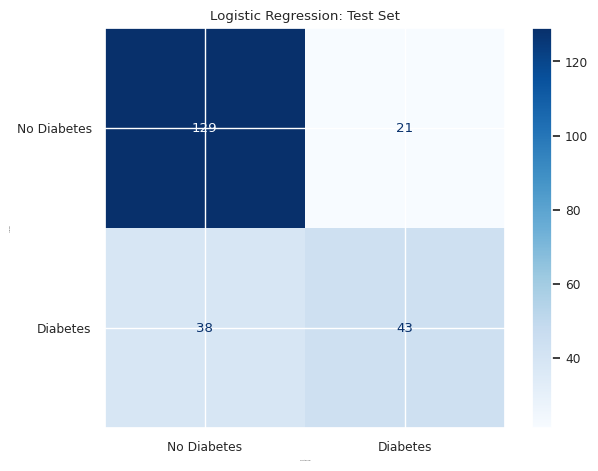

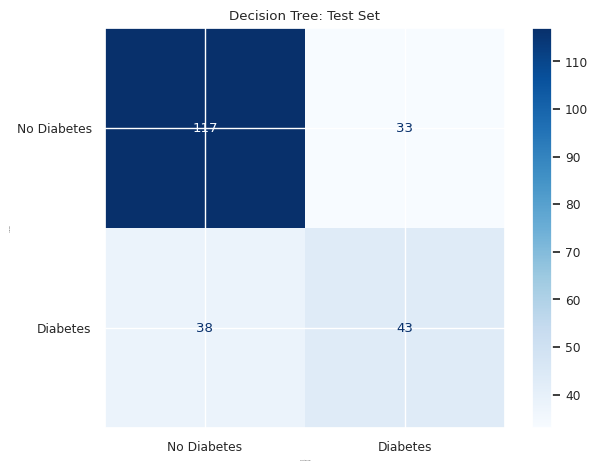

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.745,0.531,0.672,0.593,0.836
Decision Tree,0.693,0.531,0.566,0.548,0.655


In [ ]:
# @title **Automatically preprocess, train, and evaluate ML models**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

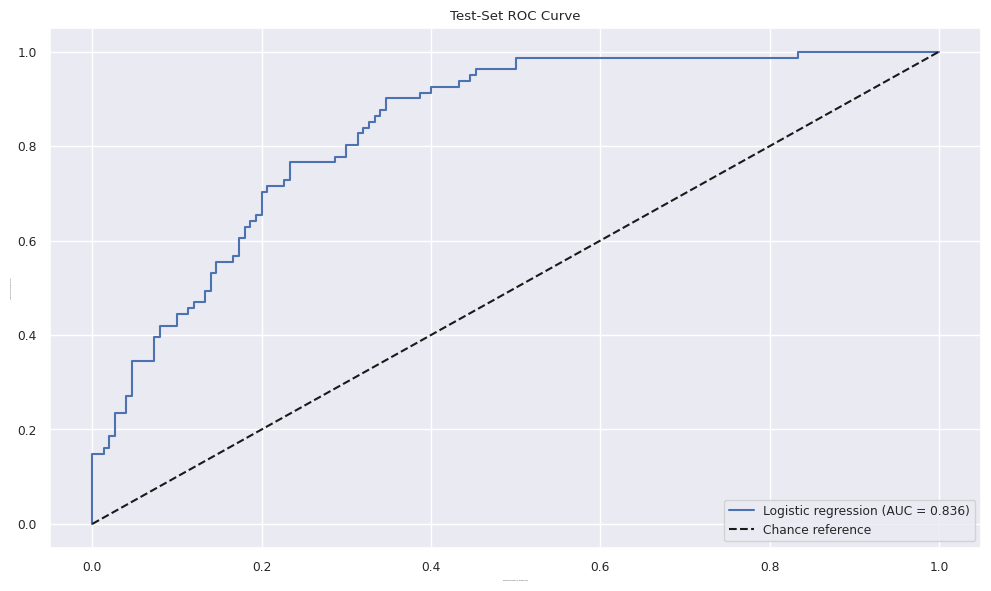

Test-set ROC AUC: 0.836


In [ ]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

In [ ]:
# @title **Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)
j_scores = tpr[finite] - fpr[finite]
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print("Criterion: maximum cross-validation sensitivity + specificity − 1.")
print("Apply this cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.443
Criterion: maximum cross-validation sensitivity + specificity − 1.
Apply this cutoff to the fitted pipeline's test-set probabilities.


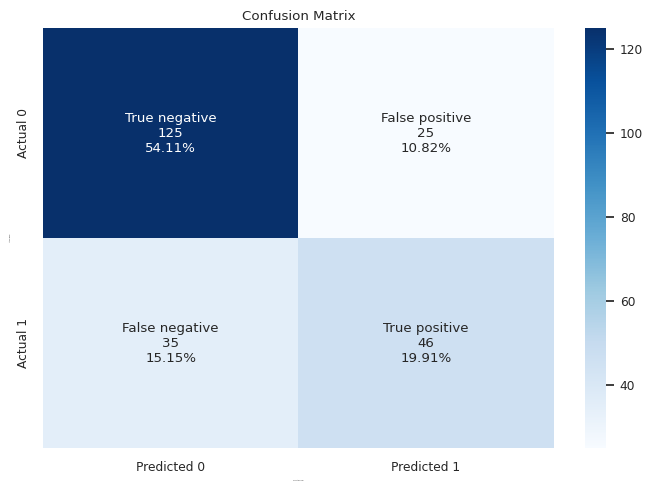

In [ ]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

In [ ]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.443
Training F1: 0.669
Test F1: 0.605


## **Decision Tree**

**Major Section Purpose:**

This last section is a more complex machine learning model that utilizes specific paramaters and ruling to classify the target according to predictor influence. This can be compared to the baseline logistic regression model above. It is the end of this pipeline and pretty much the final analytical result.

**Conditional Logic in the Workflow:**

There are similar points of conditional logic being used in the model to ensure that all inputs are correct. It checks for enough observations to conduct cross validation again. It also has some conditional statemnst for displaying output, specifically when excluding features of low importance.

**Statistical and Machine Learning Methods:**

This is the strongest example of a machine learning method being utilized. The tree depths, paramaters and outputs are all displayed to be compared. The confusion matrix and variable importances are key to this model.

**Influence of Dataset Characteristics/User-Defined Goals**

The dataset, in this case, the underlying predictor varibales did not need to be numerical, however they did need to be encoded if they were strings. Therefore the predictor characteristics did not define the model here. Additionally, no scaling of the data was needed here, as the tree can handle this issue without consequences. Therefore, the user's goals were not fine tuned or changed due to the requirements of the model. However, this final model did provide final insight considered the main output.

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [ ]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


In [ ]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.682
Selected parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_leaf_nodes': 10, 'classifier__min_samples_leaf': 5}


In [ ]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


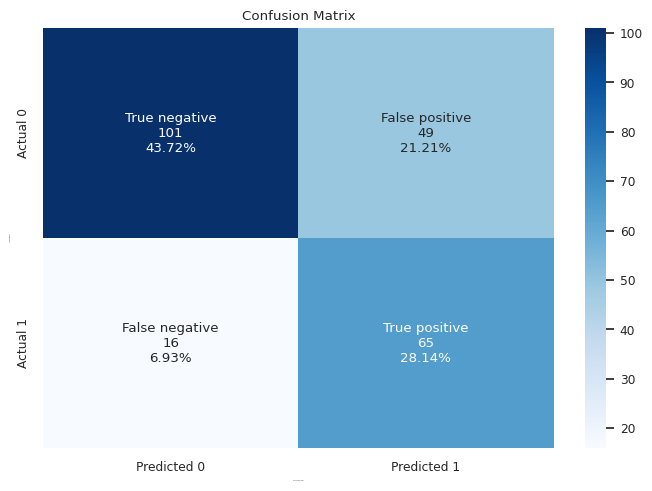

In [ ]:
# @title **Display confusion matrix for the tuned decision tree**

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)


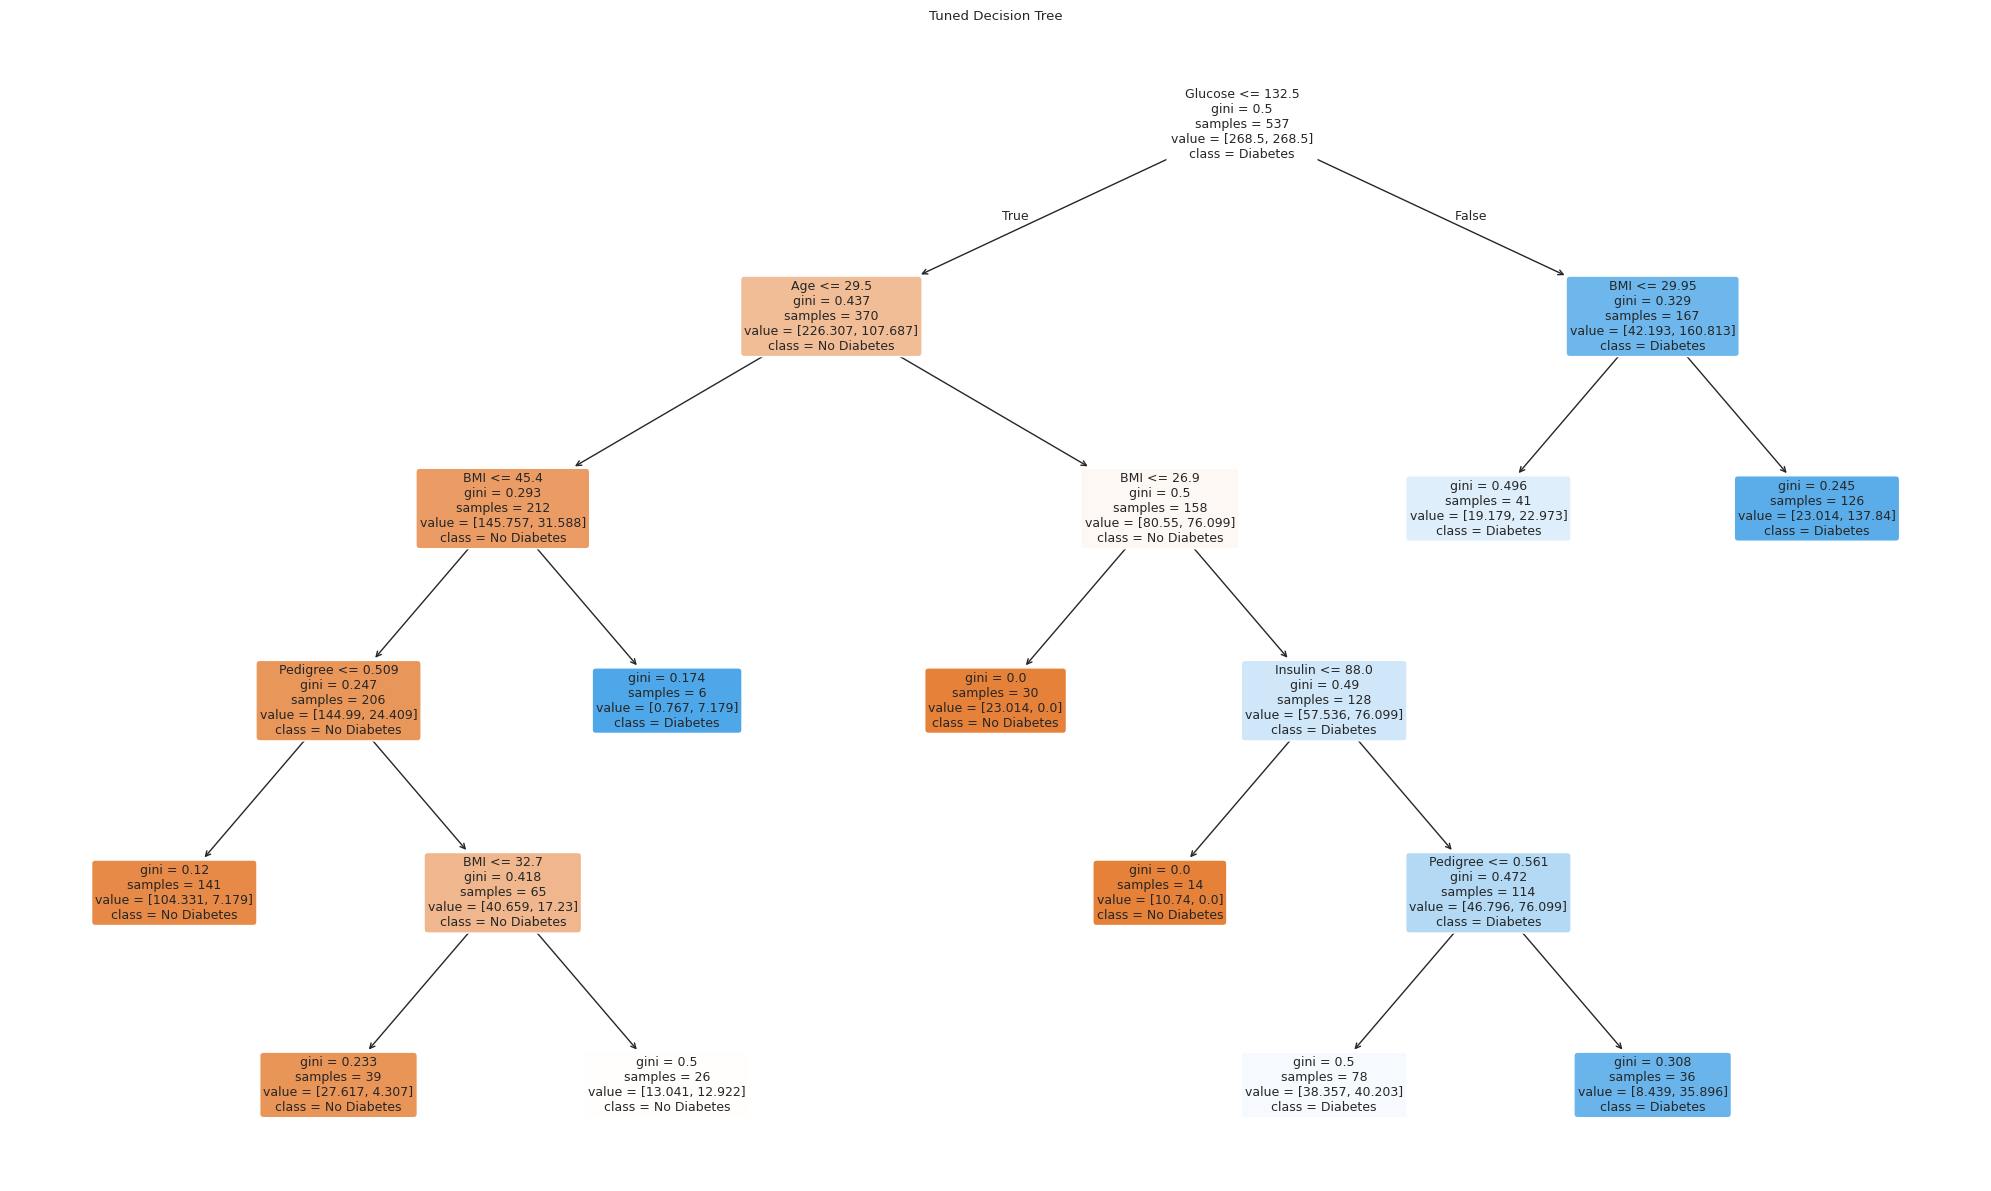

In [ ]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()


In [ ]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Glucose,0.464
1,BMI,0.265
2,Age,0.131
3,Pedigree,0.076
4,Insulin,0.063
5,Skin_Thickness,0.000
6,Pregnancies,0.000
7,D_BP,0.000


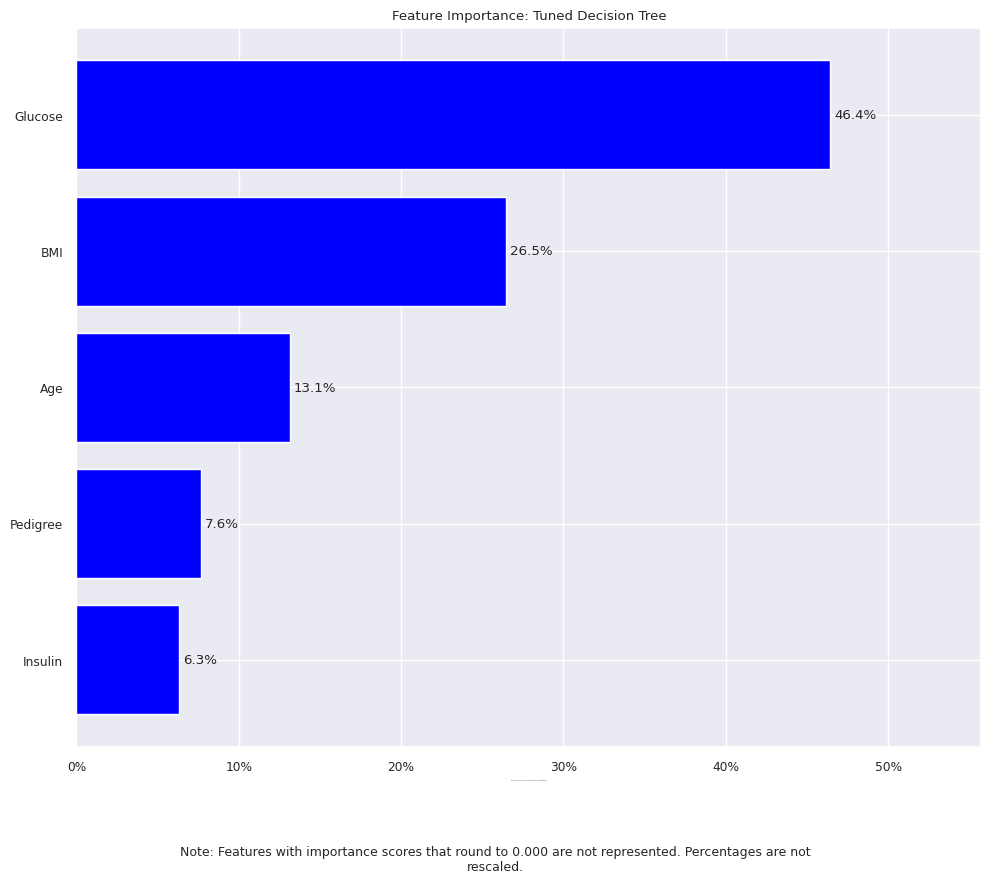

Highest-ranked features in this fitted tree:
- Glucose: 46.4%
- BMI: 26.5%
- Age: 13.1%

Excluded features (importance rounds to 0.000): Pregnancies, D_BP, Skin_Thickness

These percentages describe each feature's share of total impurity reduction, not its effect on diabetes risk.


In [ ]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on diabetes risk."
)

In [ ]:
# Second Modification
# More complex/deep tree


complex_tree = DecisionTreeClassifier(
    max_depth=12,
    random_state=42
)

complex_tree.fit(X_train, y_train)

# Evaluate the simpler tree
get_metrics_score(complex_tree)

Metric         Training       Test
Accuracy          0.985      0.727
Recall            0.968      0.568
Precision         0.989      0.622
F1                0.978      0.594


[0.9851024208566108,
 0.7272727272727273,
 0.9679144385026738,
 0.5679012345679012,
 0.9890710382513661,
 0.6216216216216216,
 0.9783783783783784,
 0.5935483870967742]

# Second Modification - Tree of Depth = 12

**What Did I Change?**

I added a modified decision tree with a depth of 12, which is higher than the other ones previosly tested in the pipeline

**Why Appropriate?**

I added this additional model to ensure that we weren't missing out on better model performance with a more complex tree. The previous tree only tested depths 8 and under.

**Output:**

The output of my additional tree found the test metrics to be quite poor compared to the other more simple tree. For example, my recall was 0.56, while the original tree found a recall of 0.8.

In [ ]:
# Compare final model performance
# Modification 3
models = {
    "Logistic Regression": logistic_pipeline,
    "Original Decision Tree": dtree,
    "Modified Decision Tree": complex_tree
}
comparison = []

# Loop through each model and find metrics
for name, model in models.items():
    y_pred = model.predict(X_test)

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })
# Table of comparisons
comparison_df = pd.DataFrame(comparison).set_index("Model")
# Display table
display(comparison_df.round(3))

,Accuracy,Recall,Precision,F1
Model,,,,
Logistic Regression,0.745,0.531,0.672,0.593
Original Decision Tree,0.719,0.802,0.570,0.667
Modified Decision Tree,0.727,0.568,0.622,0.594


# Third Modification - Final Comparison Table

**What Did I Change?**

I added a final clear and concise table comparing the metrics of all three models. The addition loops through and finds the test metrics for each and displays via a table.

**Why Appropriate?**

I added this final table because we want to overall understand how each model performs. This is an important comparison, as selecting the right model and tuning can highly improve results.

**Output:**

The output showed the logistic regression having the best accuracy and precision, while the grid-search tree has the best recall and F1. My last simple depth = 12 tree has the worst results, only having a slight edge in accuracy. For predicting diabetes, recall should be considered the most important metric, therefore the original decision tree is a good choice for continuing the project.

In [130]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import scipy
import sklearn
import statsmodels
import phik

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("phik:", phik.__version__)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
scikit-learn: 1.6.1
statsmodels: 0.15.0
phik: 0.12.5
